# 201 — GARCH · bloque conjunto ξ₁..ξ₄ · E_03 convergencia

Diagnósticos sobre cantidades invariantes a la permutación de etiquetas (log-verosimilitud, error in-sample, átomos activos, entropía, μ, g, π_j). No toca el bloque de prueba.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "201"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_201_chungEscG_1_r01_K10"
EID_MV    = "mv_escenario_201_chungEscG_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


,submodelo,variable,rhat,ess_min,geweke_max,media,sd,converge
0,bloque,loglik,1.031,6.368,8.516,-1185.605,25.643,False
1,bloque,mse_in,1.028,171.090,5.076,0.692,0.004,False
2,bloque,N_activos,1.053,48.664,1.624,12.440,8.419,False
3,bloque,entropia,1.001,9.727,4.334,0.408,0.133,False
4,bloque,mu,1.119,40.667,0.544,1.131,0.555,False
...,...,...,...,...,...,...,...,...
69,uni_10,entropia,1.036,3.984,3.235,0.872,0.346,False
70,uni_10,mu,1.009,12.112,2.418,0.390,0.571,False
71,uni_10,g,1.013,38.777,3.736,1.811,1.573,False
72,uni_10,pi[coef_10_lag1],1.120,35.651,2.346,0.526,0.299,False


{'gamma_rango_loglik_medio': 885.1143897568131, 'gamma_no_finito': 0, 'min_por_iter': 0.6902367521145831}


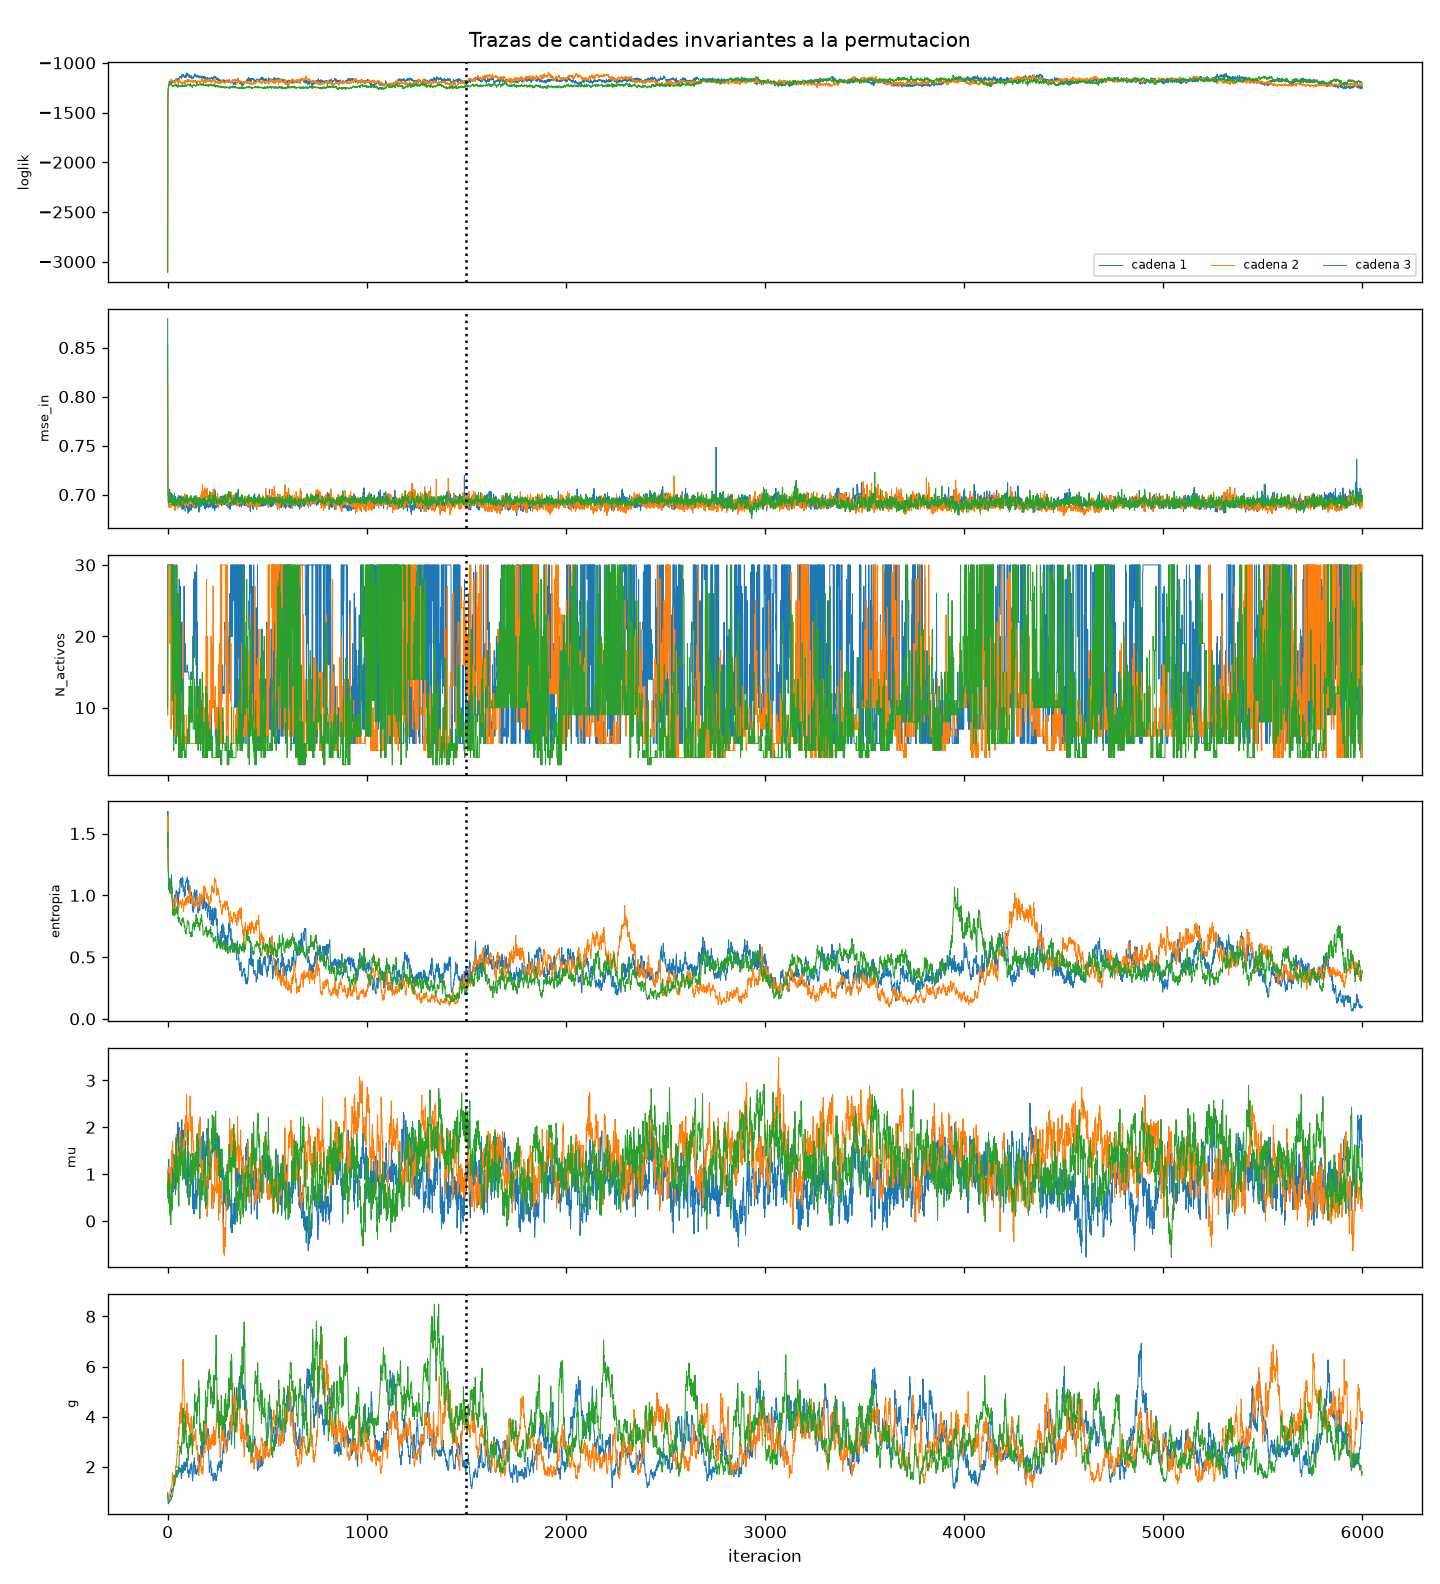

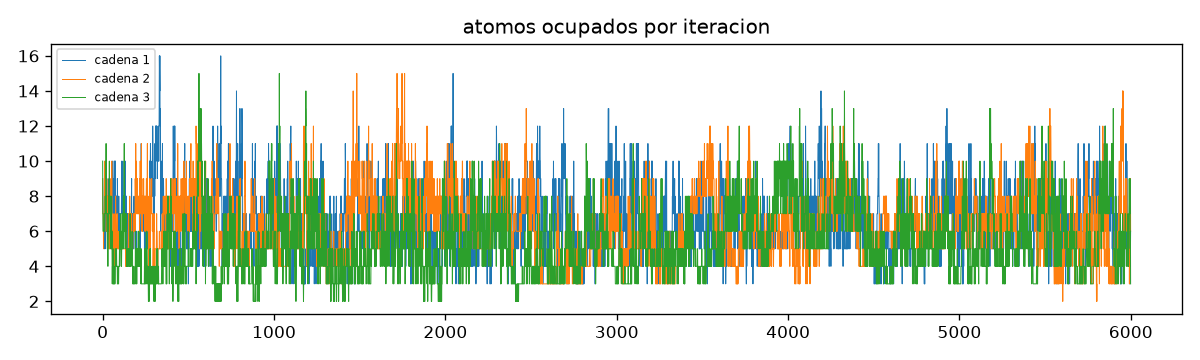

In [3]:
paths = paths_de(EID, DOMINIO)
c = convergencia.paso03(paths, N_CHAINS)
display(c["diagnosticos"].round(3)); print(c["extra"])
display(Image(filename=str(paths["out_report"] / "40_trazas.png")))
display(Image(filename=str(paths["out_report"] / "44_ocupacion.png")))

In [4]:
display(c["pip"].round(3))
pp = c["pip"].set_index("predictor")
ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()

,submodelo,predictor,pi_j,frac_atomos_ocupados_con_j
0,bloque,coef_1_lag1,0.861,0.906
1,bloque,coef_2_lag1,0.840,0.879
2,bloque,coef_3_lag1,0.758,0.781
3,bloque,coef_4_lag1,0.562,0.519
4,bloque,coef_5_lag1,0.373,0.309
5,bloque,coef_6_lag1,0.247,0.162
6,bloque,coef_7_lag1,0.200,0.119
7,bloque,coef_8_lag1,0.224,0.153
8,bloque,coef_9_lag1,0.254,0.181
9,bloque,coef_10_lag1,0.189,0.115


C:\Users\56jua\AppData\Local\Temp\ipykernel_35592\767643145.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax = pp[["pi_j", "frac_atomos_ocupados_con_j"]].plot.bar(figsize=(12, 3.5)); ax.set_title("inclusión por predictor"); plt.show()
